# Comparación de modelos

El siguiente documento presenta los entrenamientos de varios modelos usando datos agregados del experimento 1st_test. este sirve como punto de partida y comparación para arquitecturas más complejas.

Los modelos empleados son: 
- Convolutional Neural Network (CNN)
- Long Short-Term Memory (LSTM)
- Recurrent Neural Network (RNN)
- Deep Neural Network (DNN)


 

El conjunto de datos usado se componen de 17.248 filas y 21 columnas. En este cada fila corresponde a una medición del experimento 1st_test, es el primero de 3 experimentos que conforman el dataset [IMS-Rexnord Bearing](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) realizado en la universidad de Cincinnati cuyos investigadores dispusieron datos sobre viabraciones elementos rodantes. Las columnas corresponde a diferentes parámetros y estadísticos, algunos de ellos son: amplitud máxima, amplitud promedio, error cuadrático medio, varianza, desviación estándar, entre otros.

En este documento se emplea el conjunto de datos descrito, pero modificado como se describe en el archivo `TF_Generador_Datasets.ipynb` para generar un solo conjunto de datos tabulados. Para entrenar los modelos en el conjunto de datos compuesto de 21 columnas y 17.248 filas se agrupó cada 8 filas, correspondiente a cada sensor del experimento 1st_test,  para crear un tensor de la forma (2156 filas , 8 sensores, 21 columnas). Este proceso de agrupación permite que los modelos entiendan la relacion entre los canales de los experimentos, sin embargo esto provoca que se pierdan algunas etiquetas asignadas a cada canal, siendo orginalmente 7, sólo se utilizan 4.

# Correciones
En esta v3, se realizaron las siguientes modificaciones:
- Realizar escalado posterior a la separación del dataset (data leakage)
- Se separó el dataset en train (80%), validation (10%), test (20%).


# Tabla de resultados 

TEST 

| MODELO       | PRECISIÓN    | RECALL       |  F1 - SCORE  | 
|--------------|--------------|--------------|--------------|
| XGBoost      | 0.99         | 0.97         |  0.98        |
| CNN          | 0.96         | 0.93         |  0.95        |
| RNN          | 0.98         | 0.98         |  0.98        |
| LSTM         | 0.97         | 0.94         |  0.95        |
| DNN          | 0.98         | 0.95         |  0.96        |


VALIDATION

| MODELO       | PRECISIÓN    | RECALL       |  F1 - SCORE  | 
|--------------|--------------|--------------|--------------|
| XGBoost      | 0.99         |  0.97        | 0.98         |
| CNN          | 0.93         |  0.99        | 0.95         |
| RNN          | 0.95         |  0.98        | 0.97         |
| LSTM         | 0.98         |  0.90        | 0.93         |
| DNN          | 0.95         |  0.95        | 0.95         |

## Resultados de Entrenamiento

### XGBoost
![XGBoost](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_XGBoost_test.png)
![XGBoost](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_XGBoost_valid.png)

### CNN
![CNN](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_CNN_test.png)
![CNN](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_CNN_valid.png)

### RNN
![RNN](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_RNN_test.png)
![RNN](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_RNN_valid.png)

### LSTM
![LSTM](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_LSTM_test.png)
![LSTM](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_LSTM_valid.png)

### DNN
![DNN](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_DNN_test.png)
![DNN](artefactos/artefactos_train_v3/entrenamiento_agregados_v3_DNN_valid.png)



# Declaración de librerías


In [1]:
# LIBRERIAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns

2026-04-13 14:05:10.368987: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-13 14:05:10.369076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-13 14:05:10.406975: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-13 14:05:10.475401: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 14:05:11.583494: W tensorflow/compiler/tf2

In [2]:
import keras_tuner as kt
# métrica F1 macro compatible con multiclase
class F1MacroScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives  = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true_flat    = tf.cast(tf.reshape(y_true, [-1]), tf.int64)

        # one-hot encoding vectorizado — sin loops
        y_true_oh = tf.one_hot(y_true_flat,    self.num_classes)  # (batch, num_classes)
        y_pred_oh = tf.one_hot(y_pred_classes, self.num_classes)  # (batch, num_classes)

        self.true_positives.assign_add(
            tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        )
        self.false_positives.assign_add(
            tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0)
        )
        self.false_negatives.assign_add(
            tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0)
        )

    def result(self):
        precision    = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall       = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        for var in self.variables:
            var.assign(tf.zeros_like(var))

# Limpieza y armado de tensores

In [3]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

In [4]:
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = df["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df[df["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X.append(matriz)
    
    # target del experimento
    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2156, 8, 21)
(2156,)


In [5]:
#codificacion de clases 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

num_classes = len(le.classes_)

In [6]:
le.classes_

array(['Early', 'Inminent failure', 'Normal', 'Suspect'], dtype='<U16')

In [7]:
for i, clase in enumerate(le.classes_):
    print(f"{i} → {clase}")

0 → Early
1 → Inminent failure
2 → Normal
3 → Suspect


In [8]:
from sklearn.model_selection import train_test_split

# 1. Separación sobre el 100% de los datos en Train (80%) y Test (20%) 
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Separación sobre el 80% de los datos en Train (70%) y Valid (10%)
# test_size=0.125 porque 0.125 * 0.8 = 0.1 (10% del total) 
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_temp, y_train_temp, test_size=0.125, random_state=42, stratify=y_train_temp
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train = X_train_scaled.reshape(X_train.shape)


# Para Test
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_reshaped) 
X_test = X_test_scaled.reshape(X_test.shape)

# Para Valid
X_valid_reshaped = X_valid.reshape(-1, X_valid.shape[-1])
X_valid_scaled = scaler.transform(X_valid_reshaped) 
X_valid = X_valid_scaled.reshape(X_valid.shape)

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1508, 8, 21), (1508,), (432, 8, 21), (432,))

# Arbol de clasificación (XGBoost)

Este modelo no estaba previsto para realizar entremientos, sin embargo, es ampliamente conocido por su sencillez y excelente desempleño con datos tabulares por lo que se decidió realizar un entrenamiento para observar los resultados y comparar.

In [ ]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
X_valid_2d = X_valid.reshape(X_valid.shape[0], -1)

print(X_train_2d.shape)  # (1508, 168)
print(X_test_2d.shape)   # (432, 168)
print(X_valid_2d.shape)  # (216, 168)

(1508, 168)
(432, 168)
(216, 168)


In [12]:


param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [6, 7, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

param_grid = {
    "n_estimators": [300],
    "learning_rate": [0.1],
    "max_depth": [7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    # num_class=len(classes),
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    
)

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="precision_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_2d, y_train)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [14:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [14:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [14:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.

[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  11.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=  12.2s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=  12.2s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  12.3s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  12.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  12.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=  12.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  12.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300,

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [14:05:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=4, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.1],
                         'max_depth': [7], 'n_estimators': [300],
                         'subsample': [0.8, 1.0]},
             scoring='precision_macro', verbose=2)

In [13]:
print("Mejor Precision macro CV:", grid.best_score_)
print("Mejores hiperparámetros:", grid.best_params_)

Mejor Precision macro CV: 0.9647936523906361
Mejores hiperparámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}


In [14]:
# guardar el modelo entrenado con los mejores hiperparámetros
best_model = grid.best_estimator_
best_model.save_model("./artefactos/xgboost_mejorado.json")

## Evaluación - Validation

In [15]:
best_model = grid.best_estimator_

y_valid_pred = best_model.predict(X_valid_2d)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

Accuracy: 0.9814814814814815
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.83      0.83      0.83         6
          Normal       1.00      0.98      0.99        90
         Suspect       0.97      0.99      0.98       105

        accuracy                           0.98       216
       macro avg       0.95      0.95      0.95       216
    weighted avg       0.98      0.98      0.98       216



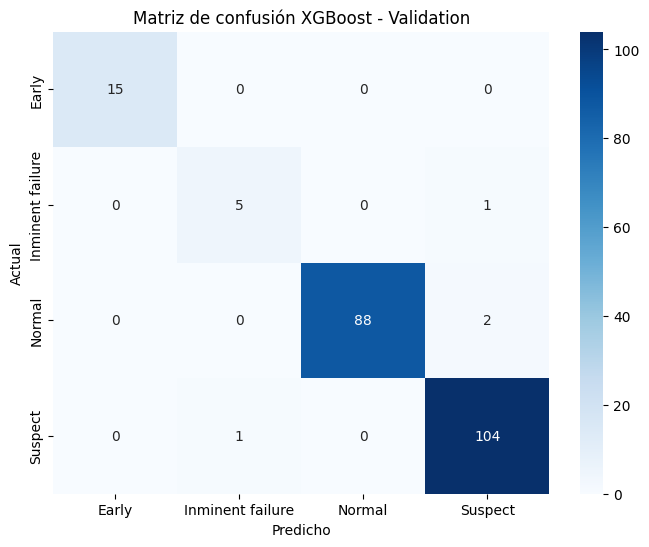

In [17]:

cm = confusion_matrix(y_valid, y_valid_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - Validation")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.show()

## Evaluación - Test


In [18]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_2d)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

Accuracy: 0.9861111111111112
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       1.00      0.91      0.95        11
          Normal       0.99      0.99      0.99       180
         Suspect       0.99      0.99      0.99       211

        accuracy                           0.99       432
       macro avg       0.99      0.97      0.98       432
    weighted avg       0.99      0.99      0.99       432



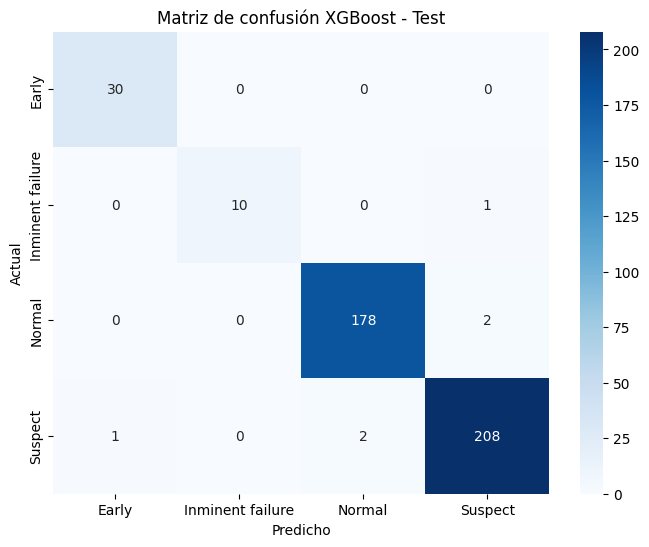

In [20]:

cm = confusion_matrix(y_test, y_test_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - Test")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.show()

# MK - CNN


In [21]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout

def make_build_model(X, num_classes):
    def build_model(hp):
        model = Sequential([
            Conv1D(
                filters=hp.Int('filters_1', min_value=16, max_value=128, step=16),
                kernel_size=hp.Choice('kernel_size_1', values=[2, 3, 5]),
                activation="relu",
                padding='same',
                input_shape=(X.shape[1], X.shape[2])
            ),
            MaxPooling1D(pool_size=2),
            Conv1D(
                filters=hp.Int('filters_2', min_value=32, max_value=256, step=32),
                kernel_size=hp.Choice('kernel_size_2', values=[2, 3, 5]),
                activation="relu",
                padding='same'
            ),
            Flatten(),
            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),
            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),
            Dense(num_classes, activation="softmax")
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', F1MacroScore(num_classes=num_classes)]
        )
        return model
    return build_model

# Uso — pasás X_train y num_classes acá
tuner = kt.Hyperband(
    make_build_model(X_train, len(np.unique(y_train))),  
    objective=kt.Objective('val_f1_score', direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='cnn_vibraciones'
)

# Callback para detener early si no mejora
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Búsqueda
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

# Ver resumen de los mejores resultados
tuner.results_summary()

# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  filters_1:   {best_hps.get('filters_1')}
  filters_2:   {best_hps.get('filters_2')}
  kernel_1:    {best_hps.get('kernel_size_1')}
  kernel_2:    {best_hps.get('kernel_size_2')}
  dense_units: {best_hps.get('dense_units')}
  dropout:     {best_hps.get('dropout')}
  lr:          {best_hps.get('lr')}
""")

Reloading Tuner from kt_results/cnn_vibraciones/tuner0.json
Results summary
Results in kt_results/cnn_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0067 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 3
filters_2: 64
kernel_size_2: 2
dense_units: 32
dropout: 0.4
lr: 0.0015980108835268547
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0056
Score: 0.9618614912033081

Trial 0084 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 5
filters_2: 32
kernel_size_2: 3
dense_units: 64
dropout: 0.2
lr: 0.00025529484165240227
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0079
Score: 0.9582096338272095

Trial 0077 summary
Hyperparameters:
filters_1: 64
kernel_size_1: 3
filters_2: 192
kernel_size_2: 3
dense_units: 160
dropout: 0.5
lr: 0.001800627430497124
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.9566235542297363

Trial 0048 

In [22]:
# Entrenar el modelo final con los mejores hiperparámetros
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

2026-04-13 14:05:36.765445: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-13 14:05:36.952032: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-13 14:05:36.953815: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Epoch 1/40


2026-04-13 14:05:38.553680: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2026-04-13 14:05:39.292989: W external/local_xla/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:504] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  /usr/local/cuda-12.2
  /usr/local/cuda
  /home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  .
You can choose the search directory by setting xla_gpu_cuda_data_dir in HloModule's DebugOptions.  For most apps, setting the environment variable XLA_FLAGS=--xla_gpu_c

151/151 [==============================] - 6s 13ms/step - loss: 0.5167 - accuracy: 0.7894 - f1_score: 0.6791 - val_loss: 0.3360 - val_accuracy: 0.8742 - val_f1_score: 0.8783
Epoch 2/40
151/151 [==============================] - 1s 5ms/step - loss: 0.2870 - accuracy: 0.8897 - f1_score: 0.8662 - val_loss: 0.3918 - val_accuracy: 0.8013 - val_f1_score: 0.8431
Epoch 3/40
151/151 [==============================] - 1s 5ms/step - loss: 0.2359 - accuracy: 0.9104 - f1_score: 0.8932 - val_loss: 0.1854 - val_accuracy: 0.9238 - val_f1_score: 0.9194
Epoch 4/40
151/151 [==============================] - 1s 5ms/step - loss: 0.1757 - accuracy: 0.9444 - f1_score: 0.9188 - val_loss: 0.1448 - val_accuracy: 0.9503 - val_f1_score: 0.9495
Epoch 5/40
151/151 [==============================] - 1s 5ms/step - loss: 0.1451 - accuracy: 0.9511 - f1_score: 0.9506 - val_loss: 0.1708 - val_accuracy: 0.9371 - val_f1_score: 0.9136
Epoch 6/40
151/151 [==============================] - 1s 5ms/step - loss: 0.1601 - accurac

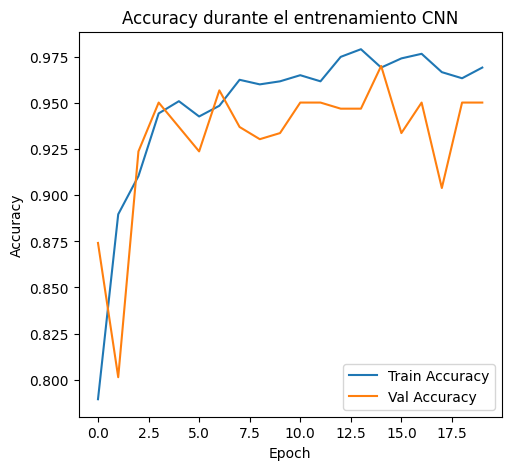

In [23]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
# guardar el modelo entrenado 
best_model.save("./artefactos/cnn_mejorada.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

7/7 [==============================] - 1s 94ms/step
Accuracy: 0.9629629629629629
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.83      0.83      0.83         6
          Normal       0.98      0.96      0.97        90
         Suspect       0.95      0.97      0.96       105

        accuracy                           0.96       216
       macro avg       0.94      0.94      0.94       216
    weighted avg       0.96      0.96      0.96       216



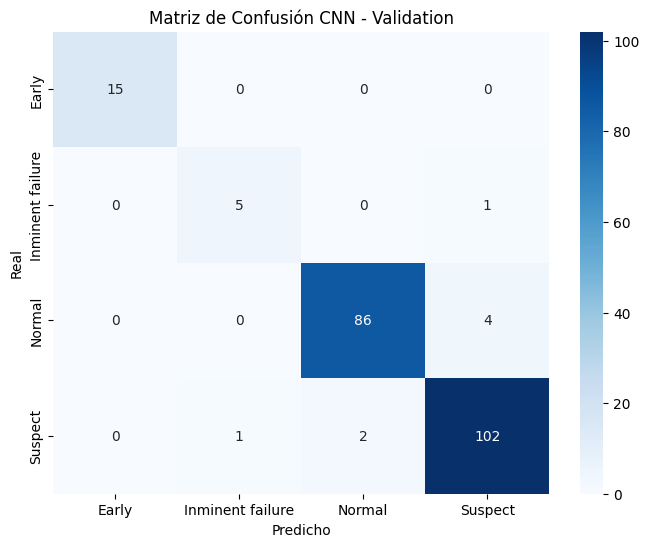

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Validation")

plt.show()

## Evaluacion - Test

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

14/14 [==============================] - 1s 44ms/step
Accuracy: 0.9652777777777778
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       1.00      0.82      0.90        11
          Normal       0.98      0.96      0.97       180
         Suspect       0.95      0.98      0.96       211

        accuracy                           0.97       432
       macro avg       0.97      0.94      0.95       432
    weighted avg       0.97      0.97      0.97       432



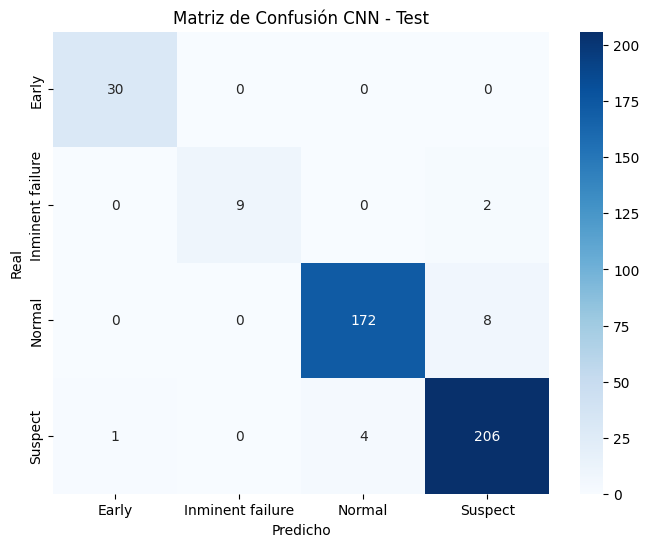

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Test")

plt.show()

# RNN


In [29]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            SimpleRNN(
                units=hp.Int('rnn_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            SimpleRNN(
                units=hp.Int('rnn_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective('val_f1_score', direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='rnn_vibraciones'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  rnn_units_1: {best_hps.get('rnn_units_1')}
  rnn_units_2: {best_hps.get('rnn_units_2')}
  dropout:     {best_hps.get('dropout_1')}
  dense_units: {best_hps.get('dense_units')}
  lr:          {best_hps.get('lr')}
""")


Reloading Tuner from kt_results/rnn_vibraciones/tuner0.json
Results summary
Results in kt_results/rnn_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0061 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.4
rnn_units_2: 80
dense_units: 64
lr: 0.0007775212063831087
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0052
Score: 0.9650602340698242

Trial 0081 summary
Hyperparameters:
rnn_units_1: 128
dropout_1: 0.30000000000000004
rnn_units_2: 112
dense_units: 192
lr: 0.0004264401157975197
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9633245468139648

Trial 0078 summary
Hyperparameters:
rnn_units_1: 64
dropout_1: 0.5
rnn_units_2: 16
dense_units: 96
lr: 0.0004645769617789411
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9623860716819763

Trial 0080 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.1
rnn_units_2: 

In [30]:

# entrenar modelo final con mejores hiperparámetros
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

Epoch 1/40
151/151 [==============================] - 4s 14ms/step - loss: 0.4515 - accuracy: 0.8217 - f1_score: 0.7478 - val_loss: 0.3858 - val_accuracy: 0.8344 - val_f1_score: 0.8524
Epoch 2/40
151/151 [==============================] - 2s 12ms/step - loss: 0.2661 - accuracy: 0.9022 - f1_score: 0.8972 - val_loss: 0.2664 - val_accuracy: 0.8974 - val_f1_score: 0.8913
Epoch 3/40
151/151 [==============================] - 2s 12ms/step - loss: 0.2085 - accuracy: 0.9196 - f1_score: 0.9082 - val_loss: 0.3080 - val_accuracy: 0.8974 - val_f1_score: 0.9025
Epoch 4/40
151/151 [==============================] - 2s 12ms/step - loss: 0.1712 - accuracy: 0.9403 - f1_score: 0.9389 - val_loss: 0.2421 - val_accuracy: 0.9172 - val_f1_score: 0.9309
Epoch 5/40
151/151 [==============================] - 2s 14ms/step - loss: 0.1352 - accuracy: 0.9511 - f1_score: 0.9254 - val_loss: 0.1614 - val_accuracy: 0.9338 - val_f1_score: 0.9199
Epoch 6/40
151/151 [==============================] - 2s 13ms/step - loss: 

In [31]:
# guardar el modelo entrenado 
best_model.save("./artefactos/rnn_mejorada.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


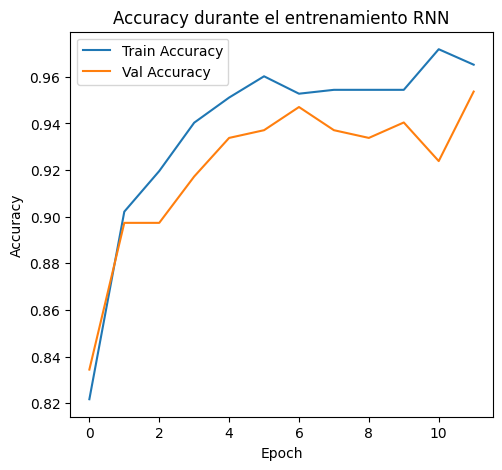

In [32]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento RNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

## Evaluación - Validation

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

7/7 [==============================] - 0s 4ms/step
Accuracy: 0.9768518518518519
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.75      1.00      0.86         6
          Normal       1.00      0.97      0.98        90
         Suspect       0.97      0.98      0.98       105

        accuracy                           0.98       216
       macro avg       0.93      0.99      0.95       216
    weighted avg       0.98      0.98      0.98       216



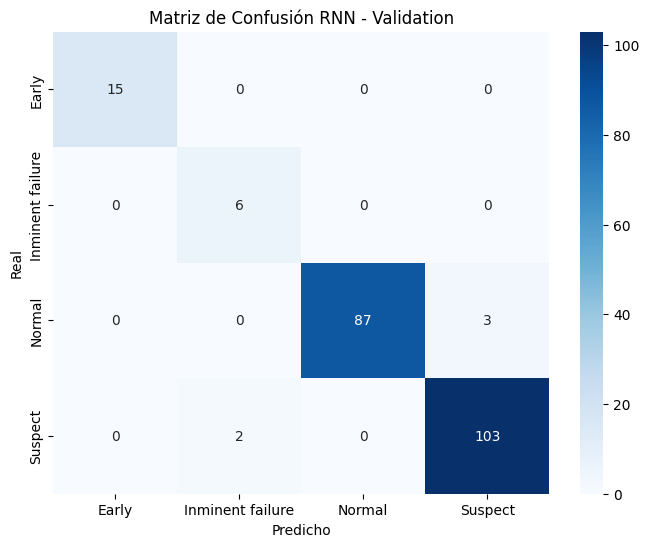

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - Validation")

plt.show()

## Evaluación - Test

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

14/14 [==============================] - 0s 4ms/step
Accuracy: 0.9745370370370371
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       1.00      1.00      1.00        11
          Normal       0.98      0.97      0.97       180
         Suspect       0.97      0.98      0.97       211

        accuracy                           0.97       432
       macro avg       0.98      0.99      0.98       432
    weighted avg       0.97      0.97      0.97       432



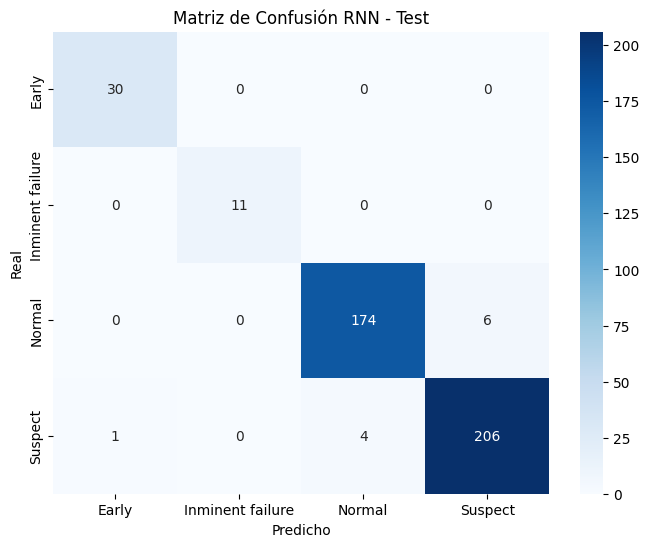

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - Test")

plt.show()

# LSTM

In [37]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            LSTM(
                units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            LSTM(
                units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective('val_f1_score', direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='lstm_vibraciones'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  lstm_units_1: {best_hps.get('lstm_units_1')}
  lstm_units_2: {best_hps.get('lstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")



Reloading Tuner from kt_results/lstm_vibraciones/tuner0.json
Results summary
Results in kt_results/lstm_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0086 summary
Hyperparameters:
lstm_units_1: 32
dropout_1: 0.4
lstm_units_2: 80
dense_units: 128
lr: 0.008326380697068002
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.957563042640686

Trial 0083 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_units: 224
lr: 0.0005167397035568562
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9575486779212952

Trial 0084 summary
Hyperparameters:
lstm_units_1: 224
dropout_1: 0.5
lstm_units_2: 16
dense_units: 160
lr: 0.003687492934224323
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0076
Score: 0.9575390219688416

Trial 0082 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128


In [38]:
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

Epoch 1/40
151/151 [==============================] - 4s 11ms/step - loss: 0.5118 - accuracy: 0.8051 - f1_score: 0.7610 - val_loss: 0.3424 - val_accuracy: 0.8576 - val_f1_score: 0.8693
Epoch 2/40
151/151 [==============================] - 1s 8ms/step - loss: 0.2739 - accuracy: 0.8972 - f1_score: 0.8859 - val_loss: 0.2819 - val_accuracy: 0.8808 - val_f1_score: 0.8511
Epoch 3/40
151/151 [==============================] - 1s 8ms/step - loss: 0.2061 - accuracy: 0.9312 - f1_score: 0.9000 - val_loss: 0.3338 - val_accuracy: 0.8709 - val_f1_score: 0.9019
Epoch 4/40
151/151 [==============================] - 1s 7ms/step - loss: 0.1675 - accuracy: 0.9478 - f1_score: 0.9226 - val_loss: 0.2043 - val_accuracy: 0.9404 - val_f1_score: 0.9318
Epoch 5/40
151/151 [==============================] - 1s 8ms/step - loss: 0.1687 - accuracy: 0.9469 - f1_score: 0.9027 - val_loss: 0.1606 - val_accuracy: 0.9371 - val_f1_score: 0.9137
Epoch 6/40
151/151 [==============================] - 1s 8ms/step - loss: 0.130

In [39]:
# guardar el modelo entrenado 
best_model.save("./artefactos/lstm_mejorada.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


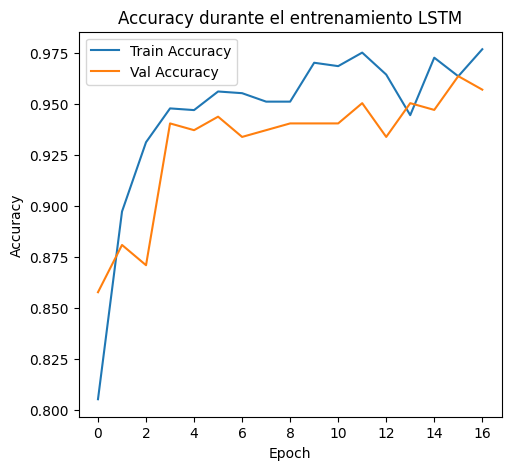

In [40]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

## Evaluación - Validation

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

7/7 [==============================] - 0s 3ms/step
Accuracy: 0.9814814814814815
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       1.00      0.67      0.80         6
          Normal       1.00      0.98      0.99        90
         Suspect       0.96      1.00      0.98       105

        accuracy                           0.98       216
       macro avg       0.99      0.91      0.94       216
    weighted avg       0.98      0.98      0.98       216



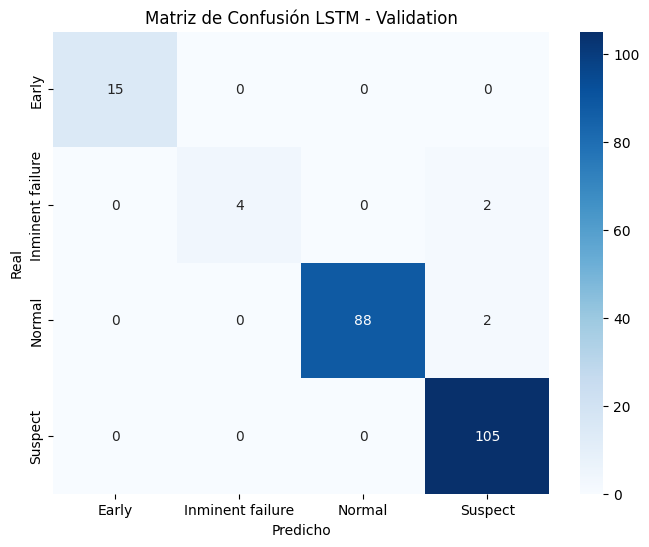

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Validation")

plt.show()

## Evaluación - Test

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.9745370370370371
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       1.00      0.82      0.90        11
          Normal       0.99      0.96      0.98       180
         Suspect       0.96      0.99      0.97       211

        accuracy                           0.97       432
       macro avg       0.98      0.94      0.96       432
    weighted avg       0.98      0.97      0.97       432



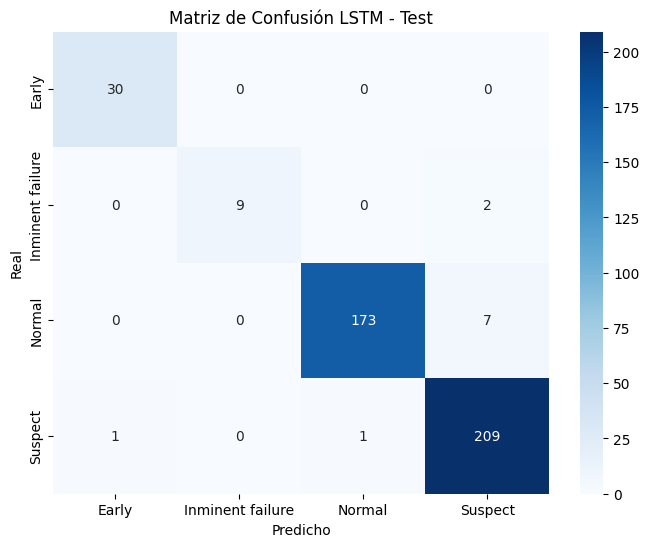

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Test")

plt.show()

# Deep Neural Network

In [45]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
X_valid_2d   = X_valid.reshape(X_valid.shape[0], -1)

print(X_train_2d.shape)  # (1724, 168)
print(X_test_2d.shape)   # (431, 168)
print(X_valid_2d.shape) # (216, 168)

(1508, 168)
(432, 168)
(216, 168)


In [46]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def make_build_model(X_train, num_classes):
    num_features = X_train.shape[1] * X_train.shape[2]

    def build_model(hp):
        model = Sequential([

            Dense(
                units=hp.Int('dense_units_1', min_value=64, max_value=256, step=32),
                activation="relu",
                input_shape=(num_features,)
            ),

            Dense(
                units=hp.Int('dense_units_2', min_value=32, max_value=128, step=32),
                activation="relu"
            ),

            Dense(
                units=hp.Int('dense_units_3', min_value=16, max_value=64, step=16),
                activation="relu"
            ),

            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective('val_f1_score', direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='mlp_vibraciones'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# aplanar X a 2D antes de entrenar
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_val_2d   = X_test.reshape(X_test.shape[0], -1)

tuner.search(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_test),
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  dense_units_1: {best_hps.get('dense_units_1')}
  dense_units_2: {best_hps.get('dense_units_2')}
  dense_units_3: {best_hps.get('dense_units_3')}
  dropout:       {best_hps.get('dropout')}
  lr:            {best_hps.get('lr')}
""")



Reloading Tuner from kt_results/mlp_vibraciones/tuner0.json
Results summary
Results in kt_results/mlp_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0087 summary
Hyperparameters:
dense_units_1: 128
dense_units_2: 64
dense_units_3: 64
dropout: 0.5
lr: 0.0038539501398167143
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.979971170425415

Trial 0077 summary
Hyperparameters:
dense_units_1: 96
dense_units_2: 64
dense_units_3: 32
dropout: 0.5
lr: 0.0014825733072079664
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.979971170425415

Trial 0078 summary
Hyperparameters:
dense_units_1: 192
dense_units_2: 32
dense_units_3: 32
dropout: 0.1
lr: 0.0002401891792157938
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.9786841869354248

Trial 0050 summary
Hyperparameters:
dense_units_1: 64
dense_units_2: 32
dense_units_3: 64
dropout: 0.30000000000000004
lr: 0.00199

In [47]:
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_test),
    callbacks=[stop_early]
)

Epoch 1/40
189/189 [==============================] - 2s 5ms/step - loss: 0.4488 - accuracy: 0.8276 - f1_score: 0.8083 - val_loss: 0.2747 - val_accuracy: 0.8912 - val_f1_score: 0.8290
Epoch 2/40
189/189 [==============================] - 1s 5ms/step - loss: 0.2716 - accuracy: 0.9138 - f1_score: 0.8712 - val_loss: 0.1830 - val_accuracy: 0.9213 - val_f1_score: 0.9156
Epoch 3/40
189/189 [==============================] - 1s 4ms/step - loss: 0.1728 - accuracy: 0.9416 - f1_score: 0.9273 - val_loss: 0.2206 - val_accuracy: 0.9329 - val_f1_score: 0.9220
Epoch 4/40
189/189 [==============================] - 1s 4ms/step - loss: 0.1703 - accuracy: 0.9489 - f1_score: 0.9366 - val_loss: 0.1078 - val_accuracy: 0.9722 - val_f1_score: 0.9617
Epoch 5/40
189/189 [==============================] - 1s 5ms/step - loss: 0.1311 - accuracy: 0.9576 - f1_score: 0.9545 - val_loss: 0.2279 - val_accuracy: 0.9167 - val_f1_score: 0.9392
Epoch 6/40
189/189 [==============================] - 1s 5ms/step - loss: 0.1143

In [48]:
# guardar el modelo entrenado 
best_model.save("./artefactos/dnn_mejorada.h5")

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


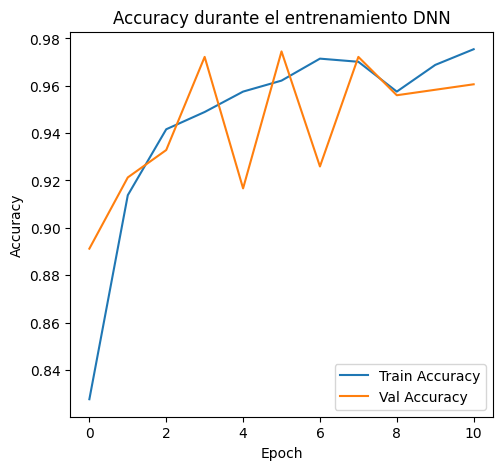

In [49]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento DNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

## Evaluación - Validation

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_valid_pred = best_model.predict(X_valid_2d)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

7/7 [==============================] - 0s 2ms/step
Accuracy: 0.9583333333333334
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       1.00      0.83      0.91         6
          Normal       1.00      0.91      0.95        90
         Suspect       0.92      1.00      0.96       105

        accuracy                           0.96       216
       macro avg       0.98      0.94      0.96       216
    weighted avg       0.96      0.96      0.96       216



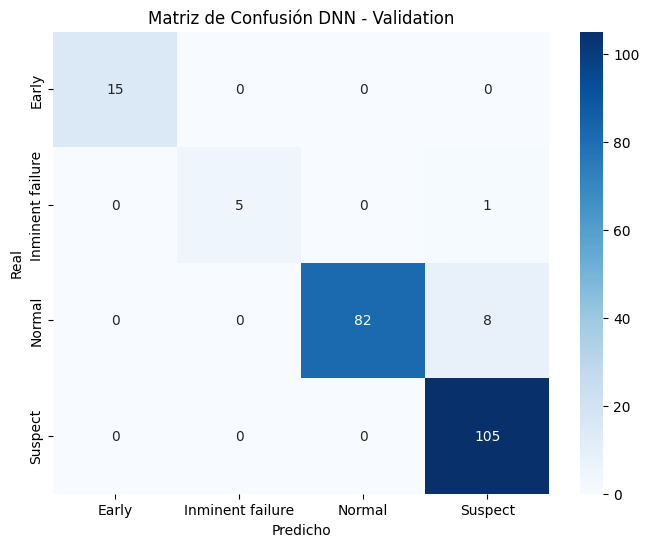

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - Validation")

plt.show()

## Evaluación - Test

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_test_pred = best_model.predict(X_test_2d)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.9606481481481481
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       1.00      0.73      0.84        11
          Normal       0.99      0.94      0.96       180
         Suspect       0.94      0.99      0.96       211

        accuracy                           0.96       432
       macro avg       0.97      0.91      0.94       432
    weighted avg       0.96      0.96      0.96       432



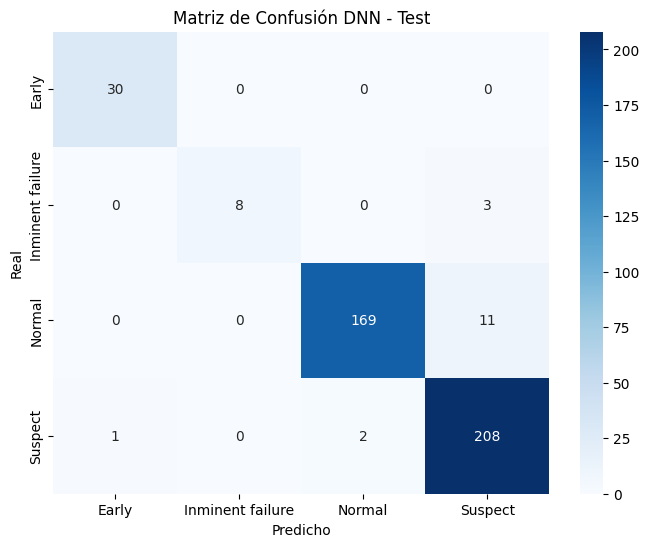

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - Test")

plt.show()